# Tech Challenge 2 - Classificação de Qualidade de Vinhos

## 1. BIBLIOTECAS

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, classification_report, confusion_matrix,
                              RocCurveDisplay)
from imblearn.over_sampling import SMOTE

sns.set(style="whitegrid")
%matplotlib inline

In [160]:
df = pd.read_csv('../data/WineQT.csv')
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,6
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,8
9,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,10


In [161]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [162]:
df.shape

(1143, 13)

### Definição da variável alvo

In [163]:
df['target'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)
df[['quality', 'target']].head(10)

,quality,target
0,5,0
1,5,0
2,5,0
3,6,0
4,5,0
5,5,0
6,5,0
7,7,1
8,7,1
9,5,0


## 2. Análise Exploratória de Dados (EDA)

### 2.1 Distribuição da variável quality (original)

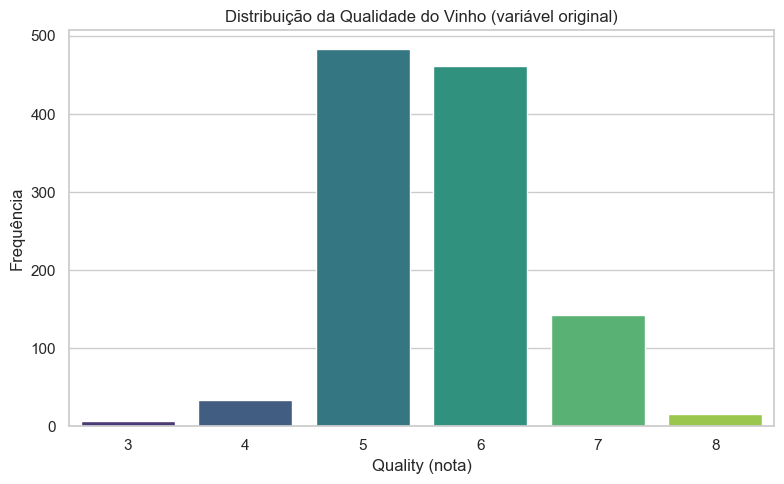

In [164]:
plt.figure(figsize=(8,5))
sns.countplot(x='quality', data=df, palette='viridis')
plt.title('Distribuição da Qualidade do Vinho (variável original)')
plt.xlabel('Quality (nota)')
plt.ylabel('Frequência')
plt.tight_layout()
plt.savefig('../results/01_distribuicao_quality.png', dpi=120)
plt.show()

### 2.2 Balanceamento das classes (target binário)

In [165]:
df['target'].value_counts()

target
0    984
1    159
Name: count, dtype: int64

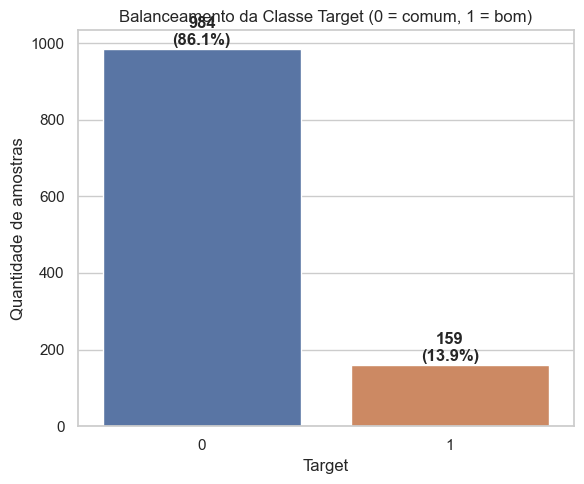

Proporção classe 1 (bom): 13.91%


In [166]:
plt.figure(figsize=(6,5))
counts = df['target'].value_counts().sort_index()
ax = sns.barplot(x=counts.index.astype(str), y=counts.values, palette=['#4C72B0','#DD8452'])
for i, v in enumerate(counts.values):
    ax.text(i, v+10, f"{v}\n({v/len(df)*100:.1f}%)", ha='center', fontweight='bold')
plt.title('Balanceamento da Classe Target (0 = comum, 1 = bom)')
plt.xlabel('Target')
plt.ylabel('Quantidade de amostras')
plt.tight_layout()
plt.savefig('../results/02_balanceamento_target.png', dpi=120)
plt.show()

print(f"Proporção classe 1 (bom): {df['target'].mean()*100:.2f}%")

### 2.3 Dados faltantes e duplicados

In [167]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
target                  0
dtype: int64

In [168]:
print("Linhas duplicadas:", df.duplicated().sum())

Linhas duplicadas: 0


### 2.4 Estatísticas descritivas

In [169]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


### 2.5 Detecção de outliers

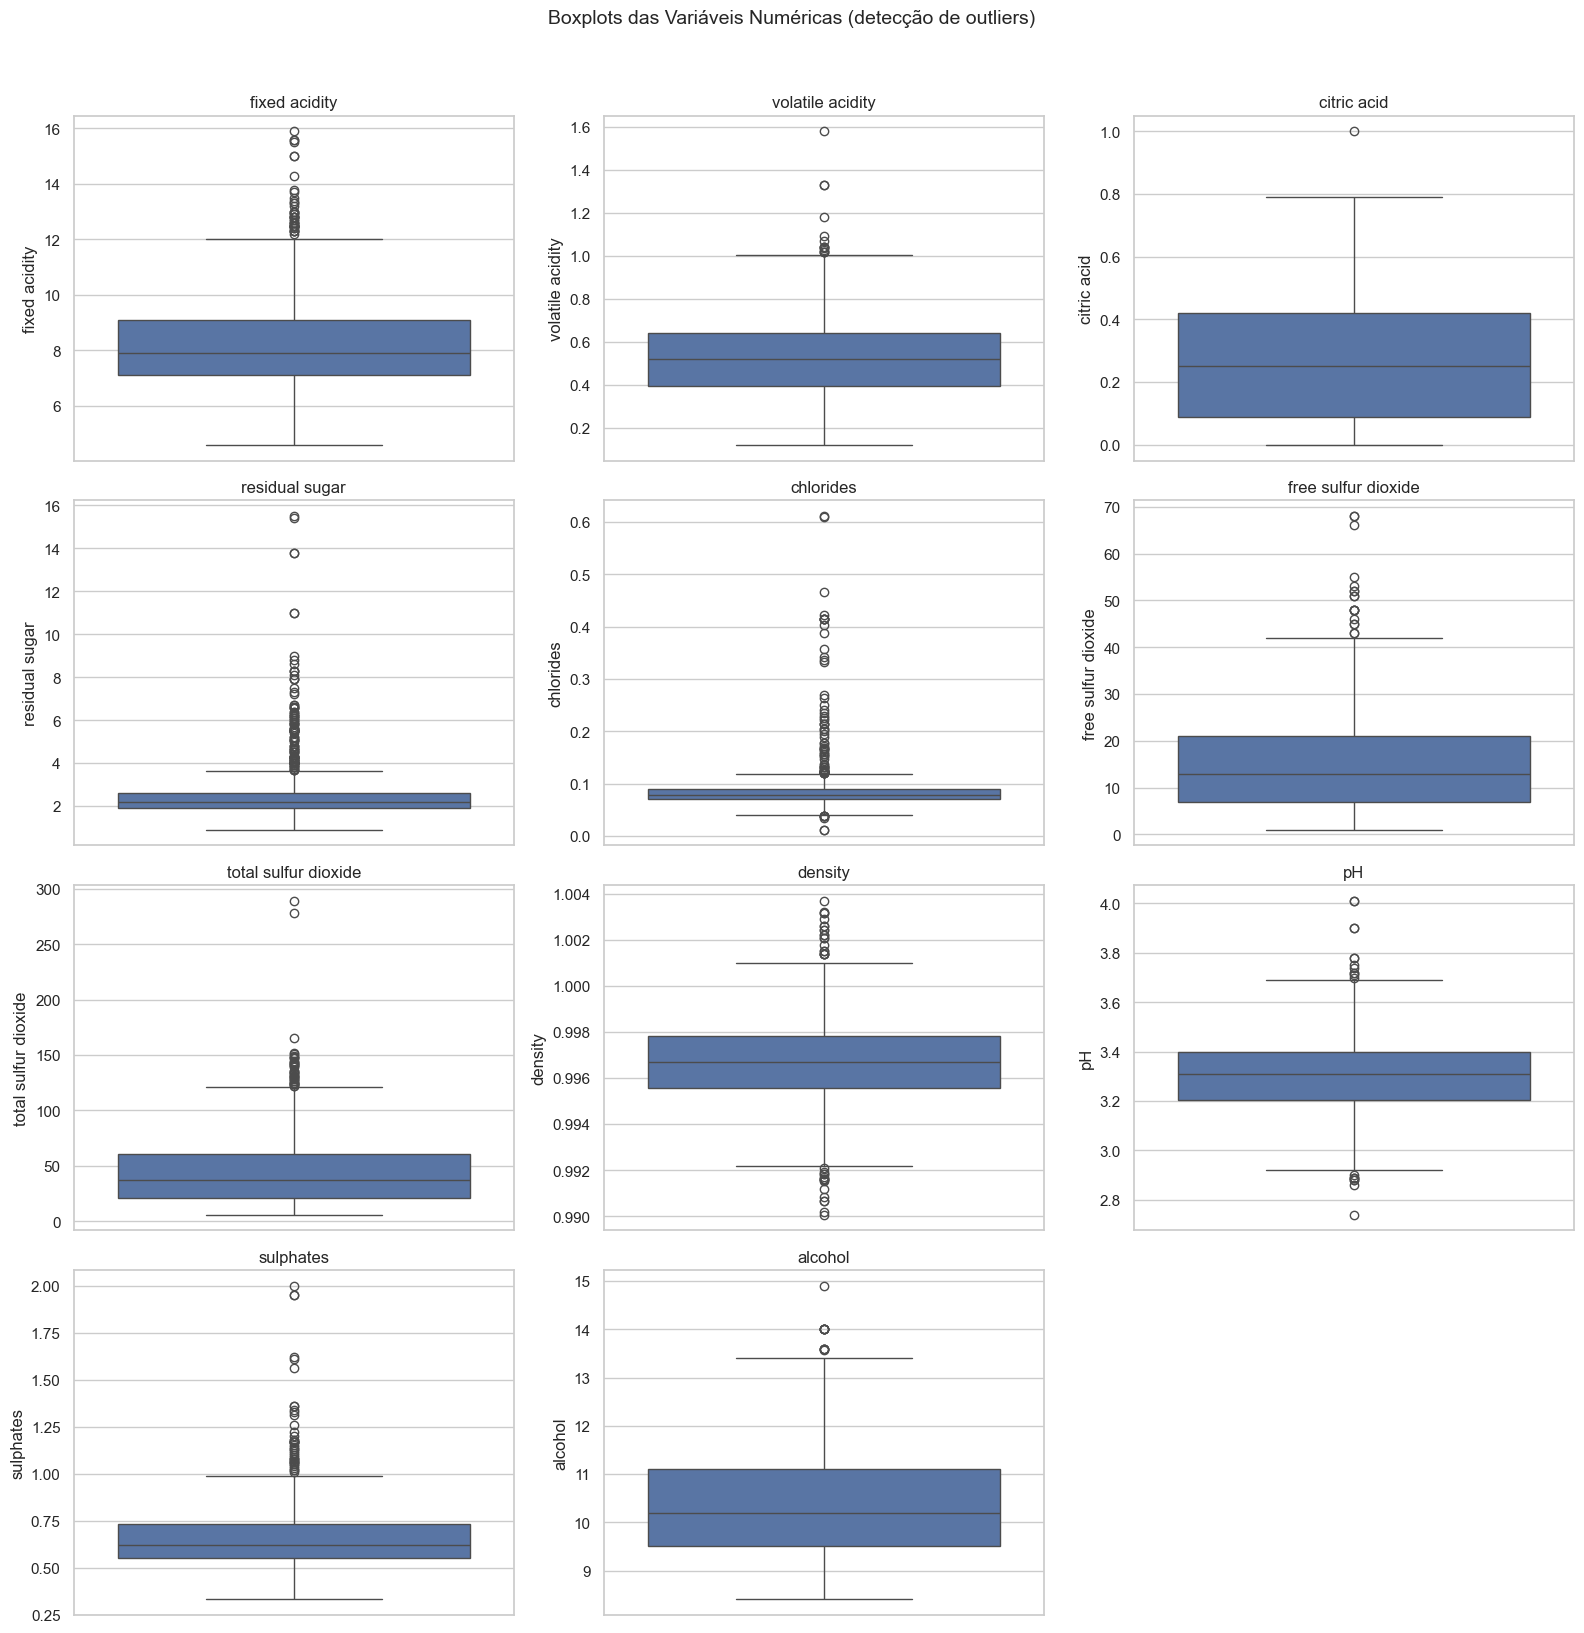

In [170]:
num_cols = [c for c in df.columns if c not in ['Id','quality','target']]

fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#4C72B0')
    axes[i].set_title(col)
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Boxplots das Variáveis Numéricas (detecção de outliers)', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('../results/03_boxplots_outliers.png', dpi=120, bbox_inches='tight')
plt.show()

In [171]:
outlier_summary = {}
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = {'n_outliers': int(n_out), 'pct': round(n_out/len(df)*100,2)}

outlier_df = pd.DataFrame(outlier_summary).T.sort_values('pct', ascending=False)
outlier_df

,n_outliers,pct
residual sugar,110.0,9.62
chlorides,77.0,6.74
fixed acidity,44.0,3.85
sulphates,43.0,3.76
total sulfur dioxide,40.0,3.50
density,36.0,3.15
pH,20.0,1.75
free sulfur dioxide,18.0,1.57
volatile acidity,14.0,1.22
alcohol,12.0,1.05


### 2.6 Teor alcoólico por classe de qualidade

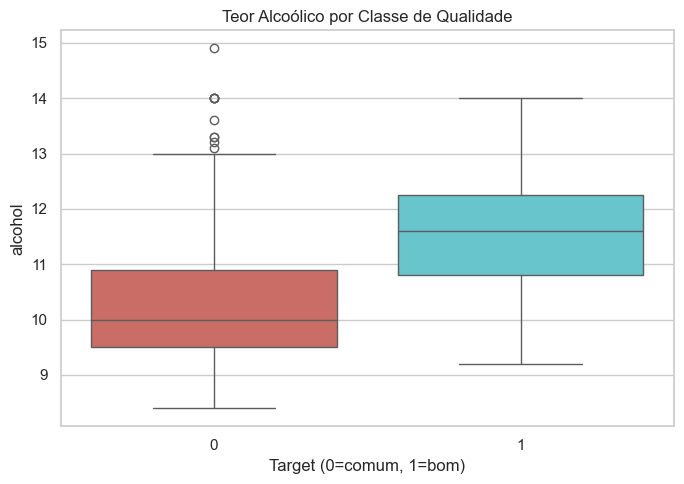

In [172]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='target', y='alcohol', palette='hls')
plt.title('Teor Alcoólico por Classe de Qualidade')
plt.xlabel('Target (0=comum, 1=bom)')
plt.tight_layout()
plt.savefig('../results/04_alcohol_vs_target.png', dpi=120)
plt.show()

### 2.7 Matriz de correlação

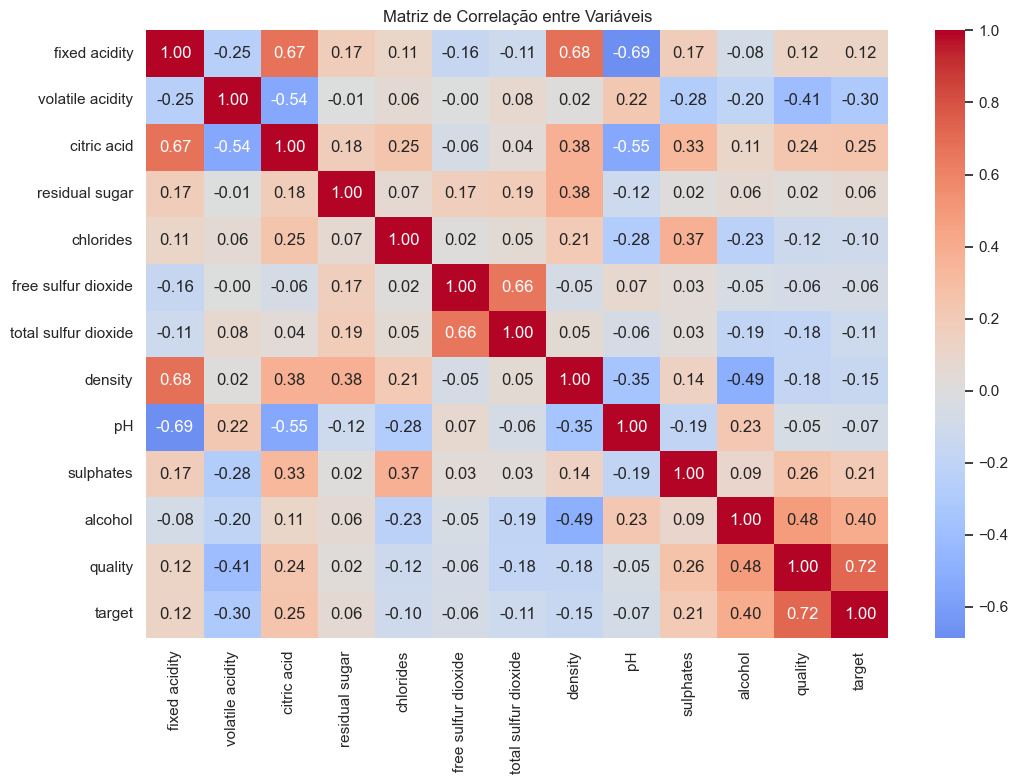

In [173]:
corr_matrix = df.drop(columns=['Id']).corr()

plt.figure(figsize=(11,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de Correlação entre Variáveis')
plt.tight_layout()
plt.savefig('../results/05_matriz_correlacao.png', dpi=120)
plt.show()

In [174]:
corr_target = corr_matrix['target'].drop('target').sort_values(ascending=False)
corr_target

quality                 0.720433
alcohol                 0.403676
citric acid             0.251146
sulphates               0.208020
fixed acidity           0.123212
residual sugar          0.064145
free sulfur dioxide    -0.055977
pH                     -0.073318
chlorides              -0.103985
total sulfur dioxide   -0.113373
density                -0.148670
volatile acidity       -0.304523
Name: target, dtype: float64

## 3. Pré-processamento de Dados

### 3.1 Tratamento de dados faltantes

In [175]:
df_clean = df.drop_duplicates().copy()
print('Shape após remoção de duplicados:', df_clean.shape)

Shape após remoção de duplicados: (1143, 14)


### 3.2 Feature Engineering

In [176]:
df_clean['acid_ratio'] = df_clean['fixed acidity'] / (df_clean['volatile acidity'] + 1e-6)
df_clean['total_acidity'] = df_clean['fixed acidity'] + df_clean['volatile acidity'] + df_clean['citric acid']
df_clean['free_so2_ratio'] = df_clean['free sulfur dioxide'] / (df_clean['total sulfur dioxide'] + 1e-6)
df_clean['alcohol_density_ratio'] = df_clean['alcohol'] / df_clean['density']
df_clean['sugar_alcohol'] = df_clean['residual sugar'] * df_clean['alcohol']

new_feats = ['acid_ratio','total_acidity','free_so2_ratio','alcohol_density_ratio','sugar_alcohol']
df_clean[new_feats + ['target']].corr()['target'].drop('target').sort_values(ascending=False)

alcohol_density_ratio    0.402657
acid_ratio               0.318700
sugar_alcohol            0.149357
free_so2_ratio           0.123614
total_acidity            0.114034
Name: target, dtype: float64

### 3.3 Separação features/target e split treino-teste

In [177]:
df_model = df_clean.drop(columns=['Id', 'quality'])

X = df_model.drop(columns=['target'])
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Treino:', X_train.shape, ' Teste:', X_test.shape)
print('\nProporção do target no treino:')
print(y_train.value_counts(normalize=True))
print('\nProporção do target no teste:')
print(y_test.value_counts(normalize=True))

Treino: (914, 16)  Teste: (229, 16)

Proporção do target no treino:
target
0    0.86105
1    0.13895
Name: proportion, dtype: float64

Proporção do target no teste:
target
0    0.860262
1    0.139738
Name: proportion, dtype: float64


### 3.4 Padronização (Standard Scaler)

In [178]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 3.5 Tratamento do desbalanceamento de classes SMOTE

In [179]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print('Distribuição do treino ANTES do SMOTE:')
print(y_train.value_counts())
print('\nDistribuição do treino DEPOIS do SMOTE:')
print(pd.Series(y_train_bal).value_counts())

Distribuição do treino ANTES do SMOTE:
target
0    787
1    127
Name: count, dtype: int64

Distribuição do treino DEPOIS do SMOTE:
target
0    787
1    787
Name: count, dtype: int64


## 4. Desenvolvimento de Modelos

In [180]:
results = []
roc_data = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:,1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec = recall_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred, zero_division=0)
    auc = roc_auc_score(y_te, y_proba) if y_proba is not None else np.nan

    results.append({'Modelo': name, 'Acuracia': acc, 'Precisao': prec,
                     'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc})
    if y_proba is not None:
        roc_data[name] = (y_te, y_proba)
    return model, y_pred

### 4.1 Baseline modelos SEM tratamento de desbalanceamento

In [181]:
gnb_base, _ = evaluate_model("Naive Bayes (baseline, sem SMOTE)", GaussianNB(),
                               X_train_scaled, y_train, X_test_scaled, y_test)

rf_base, _ = evaluate_model("Random Forest (baseline, sem SMOTE)", RandomForestClassifier(random_state=42),
                              X_train_scaled, y_train, X_test_scaled, y_test)

### 4.2 Modelos com SMOTE

In [182]:
gnb, y_pred_gnb = evaluate_model("Naive Bayes + SMOTE", GaussianNB(),
                                   X_train_bal, y_train_bal, X_test_scaled, y_test)

In [183]:
rf, y_pred_rf = evaluate_model("Random Forest + SMOTE",
                                 RandomForestClassifier(random_state=42, n_estimators=200, max_depth=12),
                                 X_train_bal, y_train_bal, X_test_scaled, y_test)

### 4.3 Alternativa ao SMOTE: class_weight='balanced' (Random Forest)

In [184]:
rf_cw, y_pred_rfcw = evaluate_model("Random Forest (class_weight=balanced)",
                                      RandomForestClassifier(random_state=42, n_estimators=200, max_depth=12,
                                                              class_weight='balanced'),
                                      X_train_scaled, y_train, X_test_scaled, y_test)

## 5. Avaliação dos Modelos

In [185]:
results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df

,Modelo,Acuracia,Precisao,Recall,F1-Score,ROC-AUC
0,Random Forest (class_weight=balanced),0.908297,0.720000,0.56250,0.631579,0.910374
1,Random Forest + SMOTE,0.877729,0.552632,0.65625,0.600000,0.909819
2,"Random Forest (baseline, sem SMOTE)",0.895197,0.653846,0.53125,0.586207,0.923699
3,"Naive Bayes (baseline, sem SMOTE)",0.825328,0.409091,0.56250,0.473684,0.826142
4,Naive Bayes + SMOTE,0.781659,0.350000,0.65625,0.456522,0.811072


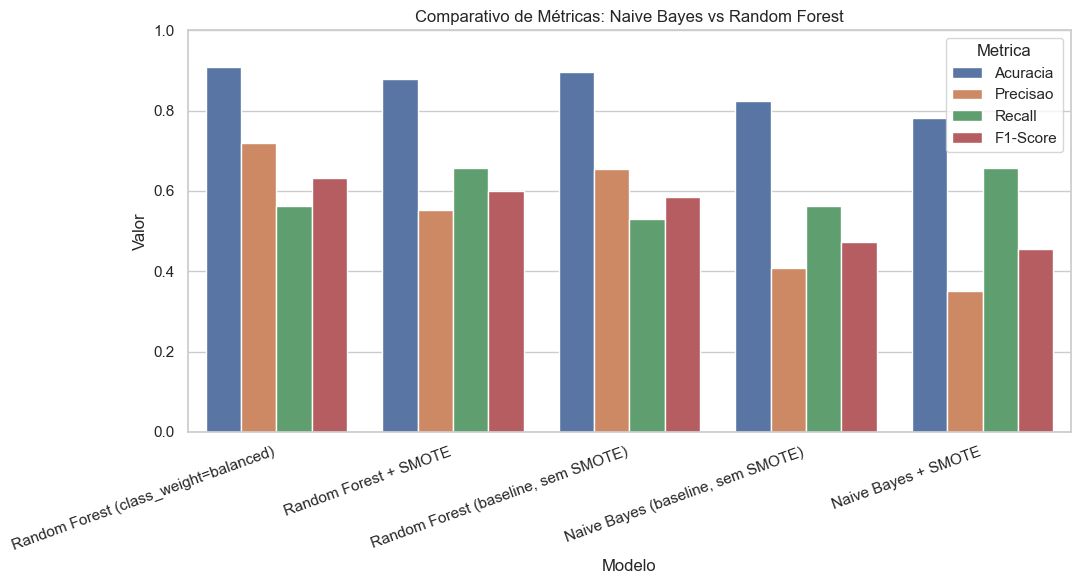

In [186]:
plt.figure(figsize=(11,6))
melted = results_df.melt(id_vars='Modelo', value_vars=['Acuracia','Precisao','Recall','F1-Score'],
                          var_name='Metrica', value_name='Valor')
sns.barplot(data=melted, x='Modelo', y='Valor', hue='Metrica')
plt.xticks(rotation=20, ha='right')
plt.title('Comparativo de Métricas: Naive Bayes vs Random Forest')
plt.ylim(0,1)
plt.tight_layout()
plt.savefig('../results/06_comparativo_metricas.png', dpi=120)
plt.show()

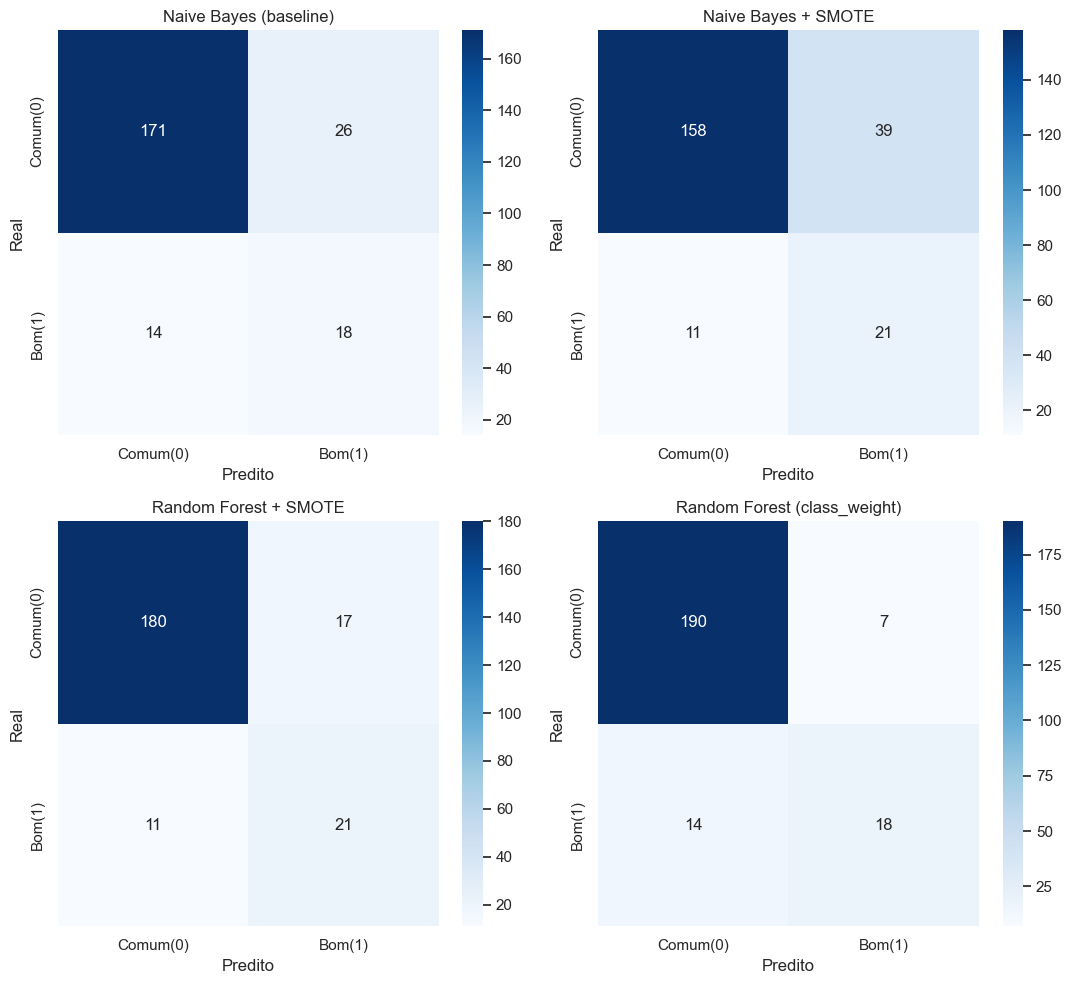

In [187]:
fig, axes = plt.subplots(2, 2, figsize=(11,10))
models_for_cm = [
    ("Naive Bayes (baseline)", gnb_base.predict(X_test_scaled)),
    ("Naive Bayes + SMOTE", y_pred_gnb),
    ("Random Forest + SMOTE", y_pred_rf),
    ("Random Forest (class_weight)", y_pred_rfcw),
]
for ax, (name, yp) in zip(axes.flatten(), models_for_cm):
    cm = confusion_matrix(y_test, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Comum(0)','Bom(1)'], yticklabels=['Comum(0)','Bom(1)'])
    ax.set_title(name)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')
plt.tight_layout()
plt.savefig('../results/07_matrizes_confusao.png', dpi=120)
plt.show()

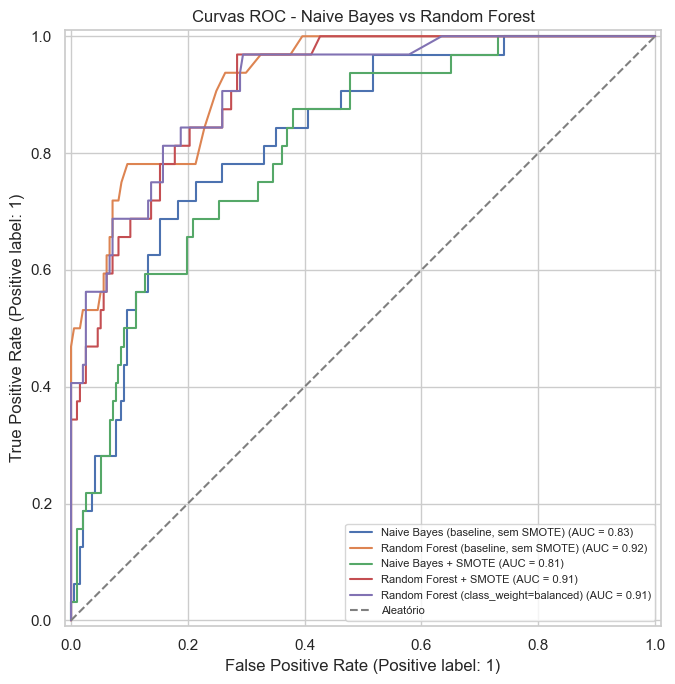

In [188]:
plt.figure(figsize=(8,7))
for name, (yte, yproba) in roc_data.items():
    RocCurveDisplay.from_predictions(yte, yproba, name=name, ax=plt.gca())
plt.plot([0,1],[0,1], linestyle='--', color='gray', label='Aleatório')
plt.title('Curvas ROC - Naive Bayes vs Random Forest')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../results/08_curvas_roc.png', dpi=120)
plt.show()

### 5.1 Relatórios de classificação completos

In [189]:
for name, yp in [("Naive Bayes (baseline)", gnb_base.predict(X_test_scaled)),
                  ("Naive Bayes + SMOTE", y_pred_gnb),
                  ("Random Forest (baseline)", rf_base.predict(X_test_scaled)),
                  ("Random Forest + SMOTE", y_pred_rf),
                  ("Random Forest (class_weight=balanced)", y_pred_rfcw)]:
    print(f"--- {name} ---")
    print(classification_report(y_test, yp, target_names=['Comum(0)','Bom(1)'], zero_division=0))
    print()

--- Naive Bayes (baseline) ---
              precision    recall  f1-score   support

    Comum(0)       0.92      0.87      0.90       197
      Bom(1)       0.41      0.56      0.47        32

    accuracy                           0.83       229
   macro avg       0.67      0.72      0.68       229
weighted avg       0.85      0.83      0.84       229


--- Naive Bayes + SMOTE ---
              precision    recall  f1-score   support

    Comum(0)       0.93      0.80      0.86       197
      Bom(1)       0.35      0.66      0.46        32

    accuracy                           0.78       229
   macro avg       0.64      0.73      0.66       229
weighted avg       0.85      0.78      0.81       229


--- Random Forest (baseline) ---
              precision    recall  f1-score   support

    Comum(0)       0.93      0.95      0.94       197
      Bom(1)       0.65      0.53      0.59        32

    accuracy                           0.90       229
   macro avg       0.79      0.74 

### 5.2 Validação cruzada

In [190]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_rf = cross_val_score(RandomForestClassifier(random_state=42, n_estimators=200, max_depth=12),
                                 X_train_bal, y_train_bal, cv=skf, scoring='f1')
cv_scores_gnb = cross_val_score(GaussianNB(), X_train_bal, y_train_bal, cv=skf, scoring='f1')

print('Random Forest - F1-scores por fold:', cv_scores_rf)
print(f'Random Forest - F1 médio: {cv_scores_rf.mean():.4f} +- {cv_scores_rf.std():.4f}')
print()
print('Naive Bayes - F1-scores por fold:', cv_scores_gnb)
print(f'Naive Bayes - F1 médio: {cv_scores_gnb.mean():.4f} +- {cv_scores_gnb.std():.4f}')

Random Forest - F1-scores por fold: [0.93865031 0.92073171 0.92638037 0.95061728 0.9470405 ]
Random Forest - F1 médio: 0.9367 +- 0.0115

Naive Bayes - F1-scores por fold: [0.82716049 0.81212121 0.80996885 0.83282675 0.83489097]
Naive Bayes - F1 médio: 0.8234 +- 0.0104


## 6. Interpretação dos Resultados

In [191]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances

alcohol                  0.149481
alcohol_density_ratio    0.141114
sulphates                0.116852
acid_ratio               0.111914
citric acid              0.080899
volatile acidity         0.064342
total sulfur dioxide     0.044531
fixed acidity            0.041132
total_acidity            0.036569
sugar_alcohol            0.036389
pH                       0.034074
density                  0.032889
free sulfur dioxide      0.029972
free_so2_ratio           0.029339
chlorides                0.027457
residual sugar           0.023046
dtype: float64

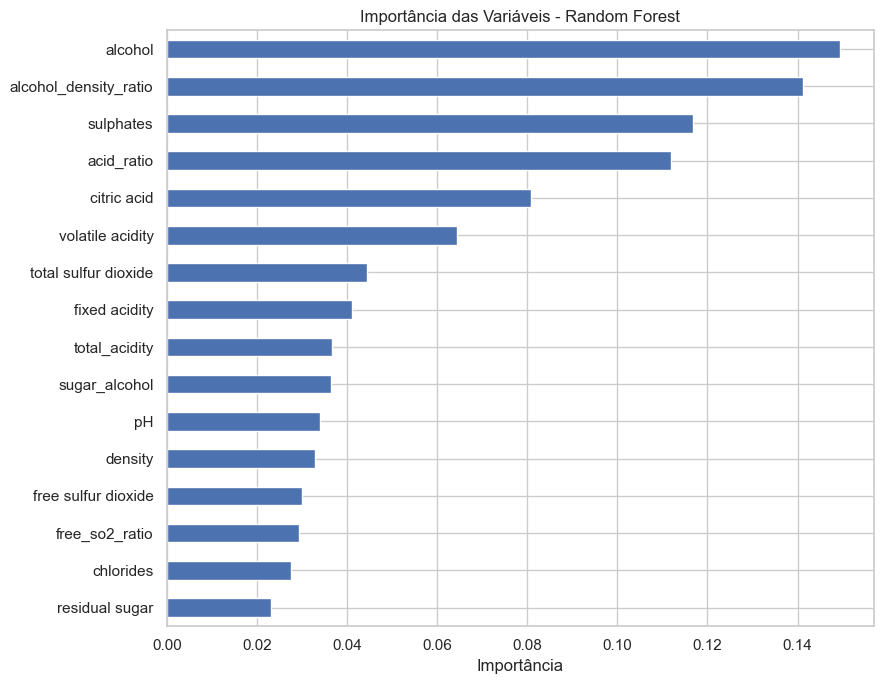

In [192]:
plt.figure(figsize=(9,7))
importances.sort_values().plot(kind='barh', color='#4C72B0')
plt.title('Importância das Variáveis - Random Forest')
plt.xlabel('Importância')
plt.tight_layout()
plt.savefig('../results/09_feature_importance.png', dpi=120)
plt.show()

## 7. Teste do Modelo em Casos Práticos

### 7.1 Função reutilizável de predição

In [193]:
def predict_wine_quality(sample: dict, model=rf_cw, scaler=scaler, feature_columns=X.columns):
    # Entrada
    df_sample = pd.DataFrame([sample])

    # Mesma engenharia de features aplicada no treino (Seção 3.2)
    df_sample['acid_ratio'] = df_sample['fixed acidity'] / (df_sample['volatile acidity'] + 1e-6)
    df_sample['total_acidity'] = df_sample['fixed acidity'] + df_sample['volatile acidity'] + df_sample['citric acid']
    df_sample['free_so2_ratio'] = df_sample['free sulfur dioxide'] / (df_sample['total sulfur dioxide'] + 1e-6)
    df_sample['alcohol_density_ratio'] = df_sample['alcohol'] / df_sample['density']
    df_sample['sugar_alcohol'] = df_sample['residual sugar'] * df_sample['alcohol']

    df_sample = df_sample[feature_columns]
    sample_scaled = scaler.transform(df_sample)

    pred = model.predict(sample_scaled)[0]
    proba = model.predict_proba(sample_scaled)[0]

    return {
        'classe_predita': int(pred),
        'rotulo': 'Bom (qualidade >= 7)' if pred == 1 else 'Comum (qualidade < 7)',
        'probabilidade_comum': round(proba[0], 4),
        'probabilidade_bom': round(proba[1], 4)
    }

### 7.2 Teste com amostras reais do conjunto de teste

In [194]:
# Seleciona 5 índices do conjunto de teste original
amostras_teste = X_test.copy()
amostras_teste['target_real'] = y_test.values

exemplos_bons = amostras_teste[amostras_teste['target_real'] == 1].head(2)
exemplos_comuns = amostras_teste[amostras_teste['target_real'] == 0].head(3)
exemplos = pd.concat([exemplos_bons, exemplos_comuns])

print("Testando o modelo em 5 amostras reais do conjunto de teste:\n")
for idx, row in exemplos.iterrows():
    sample_dict = row.drop('target_real')[
        ['fixed acidity','volatile acidity','citric acid','residual sugar','chlorides',
         'free sulfur dioxide','total sulfur dioxide','density','pH','sulphates','alcohol']
    ].to_dict()

    resultado = predict_wine_quality(sample_dict)
    real = 'Bom (qualidade >= 7)' if row['target_real'] == 1 else 'Comum (qualidade < 7)'
    acertou = 'OK' if resultado['classe_predita'] == row['target_real'] else 'ERROU'

    print(f"Amostra (índice {idx}):")
    print(f"  Real:    {real}")
    print(f"  Predito: {resultado['rotulo']}  (prob. bom: {resultado['probabilidade_bom']:.2%})  [{acertou}]")
    print()

Testando o modelo em 5 amostras reais do conjunto de teste:

Amostra (índice 162):
  Real:    Bom (qualidade >= 7)
  Predito: Comum (qualidade < 7)  (prob. bom: 21.44%)  [ERROU]

Amostra (índice 822):
  Real:    Bom (qualidade >= 7)
  Predito: Bom (qualidade >= 7)  (prob. bom: 74.53%)  [OK]

Amostra (índice 636):
  Real:    Comum (qualidade < 7)
  Predito: Bom (qualidade >= 7)  (prob. bom: 61.72%)  [ERROU]

Amostra (índice 1004):
  Real:    Comum (qualidade < 7)
  Predito: Comum (qualidade < 7)  (prob. bom: 36.65%)  [OK]

Amostra (índice 640):
  Real:    Comum (qualidade < 7)
  Predito: Comum (qualidade < 7)  (prob. bom: 16.74%)  [OK]



### 7.3 Teste com um vinho hipotético

In [195]:
vinho_hipotetico_bom = {
    'fixed acidity': 7.5,
    'volatile acidity': 0.32,
    'citric acid': 0.45,
    'residual sugar': 2.0,
    'chlorides': 0.06,
    'free sulfur dioxide': 15.0,
    'total sulfur dioxide': 40.0,
    'density': 0.9950,
    'pH': 3.3,
    'sulphates': 0.85,
    'alcohol': 12.5
}

resultado = predict_wine_quality(vinho_hipotetico_bom)
print("Vinho hipotético #1 (perfil de vinho 'bom'):")
print(vinho_hipotetico_bom)
print()
print(f"Predição: {resultado['rotulo']}")
print(f"Probabilidade de ser 'Bom':    {resultado['probabilidade_bom']:.2%}")
print(f"Probabilidade de ser 'Comum':  {resultado['probabilidade_comum']:.2%}")

Vinho hipotético #1 (perfil de vinho 'bom'):
{'fixed acidity': 7.5, 'volatile acidity': 0.32, 'citric acid': 0.45, 'residual sugar': 2.0, 'chlorides': 0.06, 'free sulfur dioxide': 15.0, 'total sulfur dioxide': 40.0, 'density': 0.995, 'pH': 3.3, 'sulphates': 0.85, 'alcohol': 12.5}

Predição: Bom (qualidade >= 7)
Probabilidade de ser 'Bom':    81.66%
Probabilidade de ser 'Comum':  18.34%


In [196]:
vinho_hipotetico_comum = {
    'fixed acidity': 7.8,
    'volatile acidity': 0.85,
    'citric acid': 0.10,
    'residual sugar': 2.2,
    'chlorides': 0.09,
    'free sulfur dioxide': 12.0,
    'total sulfur dioxide': 90.0,
    'density': 0.9978,
    'pH': 3.4,
    'sulphates': 0.55,
    'alcohol': 9.4
}

resultado = predict_wine_quality(vinho_hipotetico_comum)
print("Vinho hipotético #2 (perfil de vinho 'comum'):")
print(vinho_hipotetico_comum)
print()
print(f"Predição: {resultado['rotulo']}")
print(f"Probabilidade de ser 'Bom':    {resultado['probabilidade_bom']:.2%}")
print(f"Probabilidade de ser 'Comum':  {resultado['probabilidade_comum']:.2%}")

Vinho hipotético #2 (perfil de vinho 'comum'):
{'fixed acidity': 7.8, 'volatile acidity': 0.85, 'citric acid': 0.1, 'residual sugar': 2.2, 'chlorides': 0.09, 'free sulfur dioxide': 12.0, 'total sulfur dioxide': 90.0, 'density': 0.9978, 'pH': 3.4, 'sulphates': 0.55, 'alcohol': 9.4}

Predição: Comum (qualidade < 7)
Probabilidade de ser 'Bom':    0.00%
Probabilidade de ser 'Comum':  100.00%
